#  Spam Filter



## 1. Setup

In [8]:
import pandas as pd
import numpy as np
import math
import re
import string
import os
from collections import Counter
import matplotlib.pyplot as plt

np.random.seed(42)
print("Environment ready.")

Environment ready.


## 2. Dataset — SMS Spam Collection


In [9]:

DATA_PATH = "data/SMSSpamCollection"

if not os.path.isfile(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset file not found: {DATA_PATH}. "
        "Download the SMS Spam Collection dataset and place the "
        "SMSSpamCollection file inside the data/ folder."
    )

df = pd.read_csv(
    DATA_PATH,
    sep="\\t",
    header=None,
    names=["label", "message"],
    encoding="utf-8"
)

if len(df) < 5000:
    raise ValueError(
        f"Expected the full 5000+ SMS dataset, but only {len(df)} records were loaded. "
        "Please check that you placed the complete SMSSpamCollection file in data/."
    )

df["label"] = df["label"].str.strip().str.lower()
df = df[df["label"].isin(["ham", "spam"])].copy()

texts = df["message"].astype(str).tolist()
labels = (df["label"] == "spam").astype(int).tolist()

print(f"Dataset loaded successfully: {DATA_PATH}")
print(f"Total SMS messages: {len(df)}")
print(f"Ham messages: {(df['label'] == 'ham').sum()}")
print(f"Spam messages: {(df['label'] == 'spam').sum()}")


Dataset loaded successfully: data/SMSSpamCollection
Total SMS messages: 5574
Ham messages: 4827
Spam messages: 747


/tmp/ipykernel_2209/2172272085.py:10: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv(


## 3. Text Preprocessing (Tokenizer)



In [10]:
STOPWORDS = set('''
a an the is are was were be been being to of and or in on at for with as by
this that it its from your you i we they he she our their them his her
'''.split())

def tokenize(text: str):
    text = text.lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 1]
    return tokens

print("Custom tokenizer ready. It will be applied to the complete training/test dataset.")


Custom tokenizer ready. It will be applied to the complete training/test dataset.


## 4. Train / Test Split (from scratch)


In [11]:
def train_test_split(X, y, test_size=0.2, seed=42):
    rng = np.random.RandomState(seed)
    idx = np.arange(len(X))
    rng.shuffle(idx)
    n_test = int(len(X) * test_size)
    test_idx, train_idx = idx[:n_test], idx[n_test:]
    X_train = [X[i] for i in train_idx]
    y_train = [y[i] for i in train_idx]
    X_test = [X[i] for i in test_idx]
    y_test = [y[i] for i in test_idx]
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.2)
print(f"Train: {len(X_train)} messages ({sum(y_train)} spam)")
print(f"Test:  {len(X_test)} messages ({sum(y_test)} spam)")

Train: 4460 messages (587 spam)
Test:  1114 messages (160 spam)


## 5. TF-IDF Vectorizer


In [12]:
class TfidfVectorizer:
    '''Custom TF-IDF vectorizer implemented with core Python + NumPy + math only.'''

    def __init__(self, max_features=None):
        self.vocab_ = {}       # word -> column index
        self.idf_ = None       # idf value per column
        self.max_features = max_features

    def _tokenize(self, doc):
        return tokenize(doc)

    def fit(self, corpus):
        doc_freq = Counter()
        term_freq_total = Counter()
        tokenized_docs = [self._tokenize(d) for d in corpus]
        for tokens in tokenized_docs:
            term_freq_total.update(tokens)
            doc_freq.update(set(tokens))

        vocab_words = list(doc_freq.keys())
        if self.max_features is not None and len(vocab_words) > self.max_features:
            # keep the most frequent terms if vocab is too large
            vocab_words = [w for w, _ in term_freq_total.most_common(self.max_features)]

        self.vocab_ = {w: i for i, w in enumerate(sorted(vocab_words))}

        N = len(corpus)
        idf = np.zeros(len(self.vocab_))
        for w, i in self.vocab_.items():
            df = doc_freq[w]
            idf[i] = math.log((1 + N) / (1 + df)) + 1.0   # smoothed idf
        self.idf_ = idf
        return self

    def transform(self, corpus):
        rows = np.zeros((len(corpus), len(self.vocab_)))
        for r, doc in enumerate(corpus):
            tokens = self._tokenize(doc)
            if not tokens:
                continue
            counts = Counter(tokens)
            total_tokens = len(tokens)
            for w, c in counts.items():
                if w in self.vocab_:
                    j = self.vocab_[w]
                    tf = c / total_tokens
                    rows[r, j] = tf * self.idf_[j]
            norm = np.linalg.norm(rows[r])
            if norm > 0:
                rows[r] = rows[r] / norm         # L2 normalize
        return rows

    def fit_transform(self, corpus):
        self.fit(corpus)
        return self.transform(corpus)

    def get_counts(self, corpus):
        '''Raw word-count matrix (used for Multinomial Naive Bayes training).'''
        rows = np.zeros((len(corpus), len(self.vocab_)), dtype=float)
        for r, doc in enumerate(corpus):
            counts = Counter(self._tokenize(doc))
            for w, c in counts.items():
                if w in self.vocab_:
                    rows[r, self.vocab_[w]] = c
        return rows

vectorizer = TfidfVectorizer(max_features=3000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
X_train_counts = vectorizer.get_counts(X_train)
X_test_counts = vectorizer.get_counts(X_test)

print(f"Vocabulary size: {len(vectorizer.vocab_)}")
print(f"Train TF-IDF matrix shape: {X_train_tfidf.shape}")

# Sanity check: show top TF-IDF terms for one message
doc_idx = 0
row = X_train_tfidf[doc_idx]
top_idx = np.argsort(row)[::-1][:6]
inv_vocab = {i: w for w, i in vectorizer.vocab_.items()}
print(f"\nMessage: {X_train[doc_idx]}")
print("Top TF-IDF terms:")
for i in top_idx:
    if row[i] > 0:
        print(f"  {inv_vocab[i]:>15s} : {row[i]:.4f}")

Vocabulary size: 3000
Train TF-IDF matrix shape: (4460, 3000)

Message: Hey Boys. Want hot XXX pics sent direct 2 ur phone? Txt PORN to 69855, 24Hrs free and then just 50p per day. To stop text STOPBCM SF WC1N3XX
Top TF-IDF terms:
             porn : 0.3016
            24hrs : 0.3016
          wc1n3xx : 0.2830
             boys : 0.2764
              50p : 0.2708
           direct : 0.2660


## 6. Multinomial Naive Bayes


In [13]:
class MultinomialNaiveBayes:
    '''Multinomial Naive Bayes implemented from scratch with NumPy + math.'''

    def __init__(self, alpha=1.0):
        self.alpha = alpha  # Laplace smoothing constant

    def fit(self, X_counts, y):
        X_counts = np.asarray(X_counts, dtype=float)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        n_features = X_counts.shape[1]

        self.class_log_prior_ = np.zeros(len(self.classes_))
        self.feature_log_prob_ = np.zeros((len(self.classes_), n_features))

        for idx, c in enumerate(self.classes_):
            X_c = X_counts[y == c]
            # prior: P(class) = docs in class / total docs
            self.class_log_prior_[idx] = math.log(X_c.shape[0] / X_counts.shape[0])
            # likelihood with Laplace smoothing
            feature_counts = X_c.sum(axis=0) + self.alpha
            total = feature_counts.sum()
            self.feature_log_prob_[idx] = np.log(feature_counts / total)
        return self

    def joint_log_likelihood(self, X):
        X = np.asarray(X, dtype=float)
        # log P(c) + sum_w count(w,d) * log P(w|c)   -->  matrix multiply
        return X @ self.feature_log_prob_.T + self.class_log_prior_

    def predict_log_proba(self, X):
        jll = self.joint_log_likelihood(X)
        # log-sum-exp trick for numerical stability
        max_jll = jll.max(axis=1, keepdims=True)
        log_prob_x = max_jll + np.log(np.exp(jll - max_jll).sum(axis=1, keepdims=True))
        return jll - log_prob_x

    def predict_proba(self, X):
        return np.exp(self.predict_log_proba(X))

    def predict(self, X, threshold=0.5):
        proba = self.predict_proba(X)
        spam_col = list(self.classes_).index(1)
        return (proba[:, spam_col] >= threshold).astype(int)

nb_model = MultinomialNaiveBayes(alpha=1.0)
nb_model.fit(X_train_counts, y_train)

y_pred = nb_model.predict(X_test_counts)
print("Predicted:", y_pred)
print("Actual:   ", np.array(y_test))

Predicted: [0 0 0 ... 1 0 0]
Actual:    [0 0 0 ... 1 0 0]


## 7. Evaluation — Precision-First


In [14]:
def confusion_counts(y_true, y_pred):
    y_true = np.array(y_true); y_pred = np.array(y_pred)
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))
    return tp, tn, fp, fn

def compute_metrics(y_true, y_pred):
    tp, tn, fp, fn = confusion_counts(y_true, y_pred)
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    accuracy = (tp + tn) / len(y_true)
    return {"precision": precision, "recall": recall, "f1": f1,
            "accuracy": accuracy, "tp": tp, "tn": tn, "fp": fp, "fn": fn}

metrics = compute_metrics(y_test, y_pred)
print("=== Test Set Performance (threshold = 0.5) ===")
for k, v in metrics.items():
    print(f"  {k:>10s}: {v:.3f}" if isinstance(v, float) else f"  {k:>10s}: {v}")

=== Test Set Performance (threshold = 0.5) ===
   precision: 0.944
      recall: 0.944
          f1: 0.944
    accuracy: 0.984
          tp: 151
          tn: 945
          fp: 9
          fn: 9


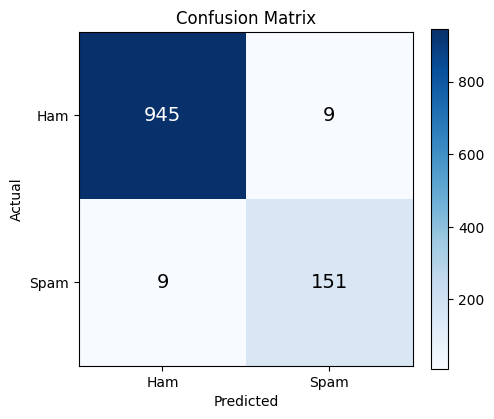

In [15]:
# Confusion matrix heatmap
tp, tn, fp, fn = confusion_counts(y_test, y_pred)
cm = np.array([[tn, fp], [fn, tp]])

fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Ham", "Spam"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Ham", "Spam"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=14)
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

### Threshold tuning — trading recall for precision


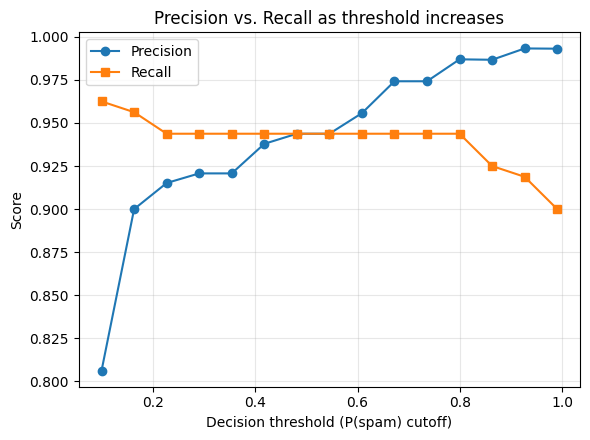

Raising the threshold pushes precision toward 1.0 (fewer false positives),
at the cost of recall (more spam slipping through as 'ham').


In [16]:
probs_test = nb_model.predict_proba(X_test_counts)[:, list(nb_model.classes_).index(1)]

thresholds = np.linspace(0.1, 0.99, 15)
precisions, recalls = [], []
for th in thresholds:
    pred_th = (probs_test >= th).astype(int)
    m = compute_metrics(y_test, pred_th)
    precisions.append(m["precision"])
    recalls.append(m["recall"])

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(thresholds, precisions, marker="o", label="Precision")
ax.plot(thresholds, recalls, marker="s", label="Recall")
ax.set_xlabel("Decision threshold (P(spam) cutoff)")
ax.set_ylabel("Score")
ax.set_title("Precision vs. Recall as threshold increases")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Raising the threshold pushes precision toward 1.0 (fewer false positives),")
print("at the cost of recall (more spam slipping through as 'ham').")

### Most spam-indicative words


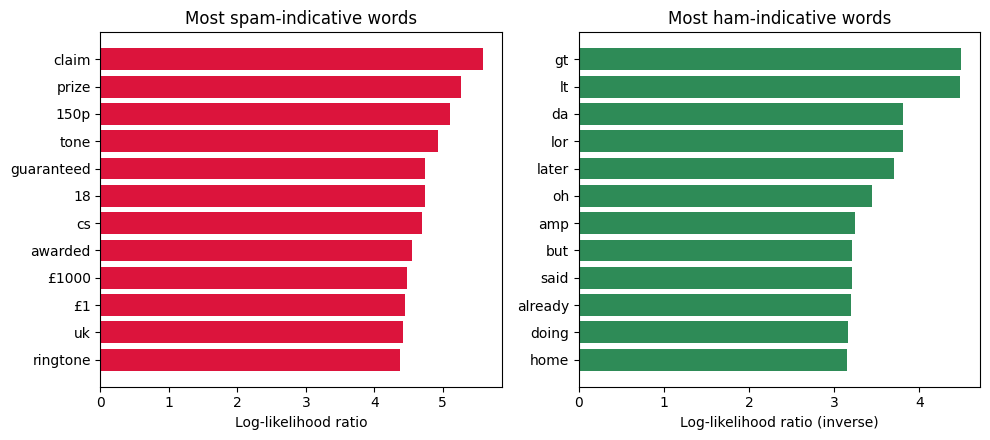

In [17]:
spam_idx = list(nb_model.classes_).index(1)
ham_idx = list(nb_model.classes_).index(0)
llr = nb_model.feature_log_prob_[spam_idx] - nb_model.feature_log_prob_[ham_idx]

inv_vocab = {i: w for w, i in vectorizer.vocab_.items()}
top_spam_words = np.argsort(llr)[::-1][:12]
top_ham_words = np.argsort(llr)[:12]

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].barh([inv_vocab[i] for i in top_spam_words][::-1], llr[top_spam_words][::-1], color="crimson")
axes[0].set_title("Most spam-indicative words")
axes[0].set_xlabel("Log-likelihood ratio")
axes[1].barh([inv_vocab[i] for i in top_ham_words][::-1], -llr[top_ham_words][::-1], color="seagreen")
axes[1].set_title("Most ham-indicative words")
axes[1].set_xlabel("Log-likelihood ratio (inverse)")
plt.tight_layout()
plt.show()

## 8. Dataset-Level Testing


In [18]:
## 8. Dataset-Level Testing

# The model is evaluated on the complete held-out test set from the loaded dataset.

test_probabilities = nb_model.predict_proba(X_test_counts)[:, list(nb_model.classes_).index(1)]
test_predictions = (test_probabilities >= 0.5).astype(int)

# Store every test-set prediction for inspection.
test_results = []
for message, actual, predicted, probability in zip(
    X_test, y_test, test_predictions, test_probabilities
):
    test_results.append({
        "message": message,
        "actual_label": "SPAM" if actual == 1 else "HAM",
        "predicted_label": "SPAM" if predicted == 1 else "HAM",
        "spam_probability": float(probability),
        "correct": bool(actual == predicted),
    })

print(f"Predictions generated for all {len(test_results)} held-out test messages.")
print(f"Correct predictions: {sum(r['correct'] for r in test_results)}")
print(f"Incorrect predictions: {sum(not r['correct'] for r in test_results)}")

# Display a small slice of the dataset predictions only for inspection;
# all test messages were processed above.
import pandas as pd
results_df = pd.DataFrame(test_results)

# Save predictions for the entire held-out dataset.
results_df.to_csv("test_predictions.csv", index=False)
print("Saved all test-set predictions to test_predictions.csv")


Predictions generated for all 1114 held-out test messages.
Correct predictions: 1096
Incorrect predictions: 18
Saved all test-set predictions to test_predictions.csv
